## DEEP LEARNING FOR FINANCE


MODULE 6 | LESSON 2


---

# **APPLICATION OF AUTOENCODERS: EXTRACTING FEATURES FROM STOCK RETURNS** 

|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** |  Neural Networks, machine learning |
|**Keywords** | Autoencoder, Principal Components, Factors |


---

## **1. INTRODUCTION**

In this notebook, we will describe how to build a basic autoencoder model with TensorFlow using stock returns data. The exercise here will illustrate the tools that we described in Lesson 1 and the typical outputs generated by autoencoders to understand the variation that drives security prices. In Lesson 4, we will extend the analysis allowing an autoencoder model to become a tool for portfolio choice.

Let's first load some libraries needed in this notebook altogether with the data. We are going to analyze 20 tech stocks and their evolution over the 2017-2022 period. Using autoencoders, we will extract the common encodings, or latent "factors", that determine the variation of stock returns and how each stock is exposed to those factors.

In [32]:
import numpy as np
import pandas as pd

In [33]:
import yfinance as yf

tickers = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "TSLA",
    "TCEHY",
    "NVDA",
    "TSM",
    "META",
    "BABA",
    "ASML",
    "AVGO",
    "ORCL",
    "CSCO",
    "ADBE",
    "CRM",
    "NFLX",
    "TXN",
    "QCOM",
    "SAP",
]
df = pd.DataFrame()
for tick in tickers:
    ydata = yf.download(tick, start="2017-01-01", end="2022-12-31")
    data = ydata["Adj Close"].pct_change()  # Daily returns
    df[tick] = data[1:]
df.index = pd.to_datetime(ydata.index[1:], format="%Y%m%d")
df = df.dropna(axis=1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Use 80% of the data as a training sample (below we will use an additional 20% of the training data for validation purposes) and the remaining 20% belongs to the test part.

In [34]:
train_size = int(0.8 * df.shape[0])
Y_train = df[: train_size + 1].to_numpy()
Y_test = df[train_size + 1 :].to_numpy()
print("Beginning of training sample: ", df.index[0])
print("End of training sample: ", df.index[train_size])
print("End of test sample: ", df.index[-1])

Beginning of training sample:  2017-01-04 00:00:00
End of training sample:  2021-10-20 00:00:00
End of test sample:  2022-12-30 00:00:00


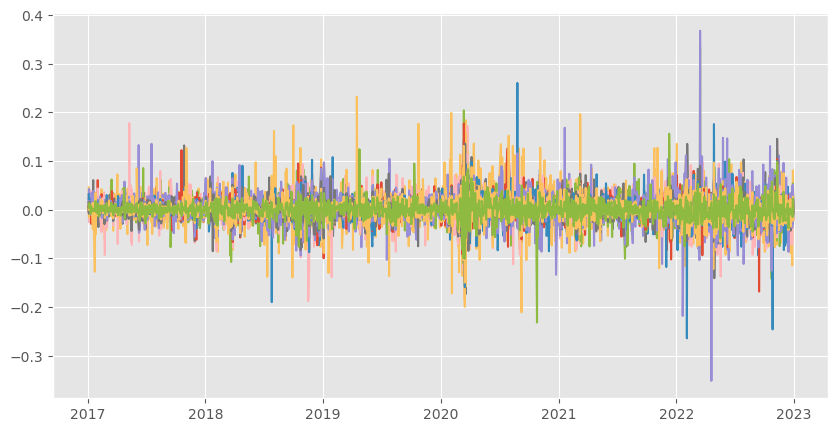

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df)
plt.show()

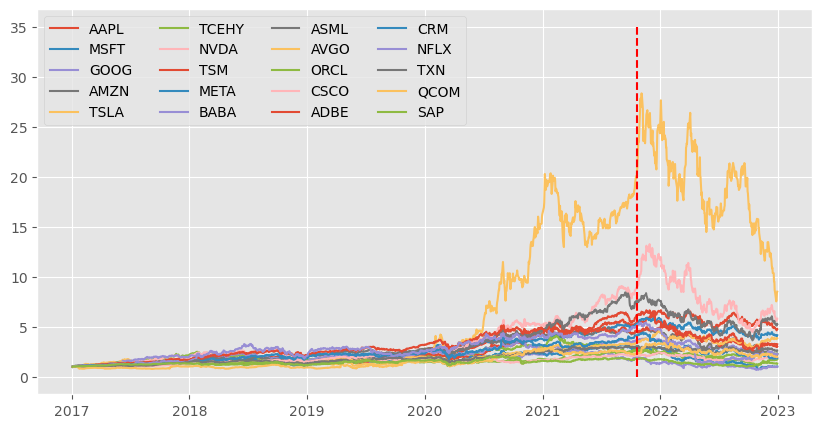

In [36]:
df_ret = pd.DataFrame()
for tick in tickers:
    df_ret[tick] = 1 + df[tick]
    df_ret[tick] = df_ret[tick].cumprod()
plt.figure(figsize=(10, 5))
plt.plot(df_ret.index, df_ret)
plt.plot([df.index[train_size + 1], df.index[train_size + 1]], [0, 35], "r--")
plt.legend(tickers, loc="upper left", ncol=4)
plt.show()

## **2. APPLYING PRINCIPAL COMPONENT ANALYSIS (PCA)**

Before building the autoencoder, we are going to perform principal component analysis (PCA) on the data. This analysis serves as a good benchmark when we later train autoencoders to learn the latent factors. 

Remember that PCA consists on a linear transformation of the data to a low-dimensional space of factors that are orthogonal between each other. Below, we perform PCA on the data, extracting the first 3 principal components. The principal components are the columns of the matrix of eigenvectors from diagonalizing the variance-covariance matrix of the data. We have chosen the first 3 principal components to explain the stock return variation of 20 stocks, meaning that we obtain three 20x1 vectors of loadings. The loadings capture how much each single stock is "exposed" to the principal component.

We can also extract the proportion of the variation of the data explained by the first 3 principal components. See how the first principal component explains more than half of the variation in the data. The second and third components explain, respectively, roughly 10 percent and 5 percent of the variation. 

The factors that drive stock returns and that are extracted from PCA represent latent variables that are sometimes hard to interpret or to give them a "name," particularly as we consider the second, third, and further components. However, when we analyze stock returns, the first principal component can be most of the time attributed to a "market factor" that generates positive comovement in returns across stocks. As we show, the loadings on this first factor are all negative across stocks (remember that the variance of $Z$ is the same as the variance of $-Z$). This confirms that the stock price of a single stock tends to move in the same direction as all the remaining stocks, and this explains more than 50% of the variation of returns.



In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(Y_train)
print(pca.components_.T)
# Cumulative share of the variation of the data predicted the factors
print(np.cumsum(pca.explained_variance_ratio_))

[[-0.21770863  0.05795462  0.02739501]
 [-0.21317684  0.07550053  0.10043476]
 [-0.19188243  0.08332636  0.12845739]
 [-0.19832327  0.0541332   0.26985221]
 [-0.32603709 -0.93832549 -0.01758464]
 [-0.20165205  0.06692994 -0.1229685 ]
 [-0.33458706  0.100926   -0.08759994]
 [-0.20028346  0.06151073 -0.27766136]
 [-0.21014414  0.0881407   0.25245869]
 [-0.19653502  0.06654704  0.02175422]
 [-0.24964113  0.07132178 -0.27880833]
 [-0.24079353  0.04948869 -0.30990396]
 [-0.13699542  0.11901001  0.03771475]
 [-0.16257958  0.11069779 -0.02544562]
 [-0.23963345  0.07765476  0.20981881]
 [-0.22288276  0.0406202   0.2740886 ]
 [-0.22568023  0.04676978  0.51694039]
 [-0.21591106  0.10901435 -0.20734674]
 [-0.22778782  0.09300192 -0.35921982]
 [-0.16479046  0.07491005 -0.0343558 ]]
[0.51528511 0.6205684  0.6767068 ]


Notice that the factors generated by PCA are indeed uncorrelated and that the loadings are orthonormal.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [38]:
# Factors (encodings) generated by PCA
pca_factors = np.dot(pca.components_, Y_train.T)
# Show that factors are uncorrelated
print(np.round(np.cov(pca_factors, rowvar=True), 5))
# Show that loadings are orthonormal
print(np.round(np.dot(pca.components_, pca.components_.T), 5))

[[ 0.00499 -0.       0.     ]
 [-0.       0.00102  0.     ]
 [ 0.       0.       0.00054]]
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


An important remark is that the loadings and factors from PCA are not unique. Any linear, orthogonal transformation of the eigenvectors also maximizes the variance generated by the projections. Different software packages may generate different solutions. However, all the solutions should explain the same amount of variation in a given dataset.

Below we perform PCA extracting the first 6 principal components.

In [39]:
pca = PCA(n_components=6)
pca.fit(Y_train)
print(pca.components_.T)
# Cumulative share of the variation of the data predicted the factors
print(np.cumsum(pca.explained_variance_ratio_))

[[-0.21770863  0.05796274  0.02749069  0.09576461  0.1068238  -0.01264112]
 [-0.21317685  0.07550231  0.1004406   0.11399525  0.12491419 -0.05863411]
 [-0.19188243  0.08332741  0.12844551  0.06108676  0.10423746 -0.05496591]
 [-0.19832329  0.05414264  0.26978362 -0.02951655 -0.01338015  0.05737311]
 [-0.32603709 -0.93832593 -0.01759009  0.0231875   0.05140137 -0.0242536 ]
 [-0.20165205  0.0669273  -0.12300446 -0.66700061  0.19814871 -0.01512626]
 [-0.33458706  0.1009232  -0.087616    0.04445785 -0.78572301 -0.30432987]
 [-0.20028346  0.06152551 -0.27758803 -0.01557412 -0.02716649 -0.00966754]
 [-0.21014414  0.08813659  0.2524638   0.06292734  0.02084794 -0.14135267]
 [-0.19653502  0.06654592  0.02177855 -0.62836075  0.05434368 -0.12272652]
 [-0.24964113  0.07132093 -0.27879008  0.04489401 -0.04899533 -0.02238728]
 [-0.24079352  0.04948249 -0.30993252  0.10366958  0.00743256  0.09293761]
 [-0.13699543  0.11900582  0.03767933  0.17712887  0.30755289 -0.15424507]
 [-0.16257957  0.11069556

You can verify that the solution with 3 principal components is nested by the solution when we extract additional principal components. That is, the loadings on the first three components and the variation explained by them is the same as we obtained above.

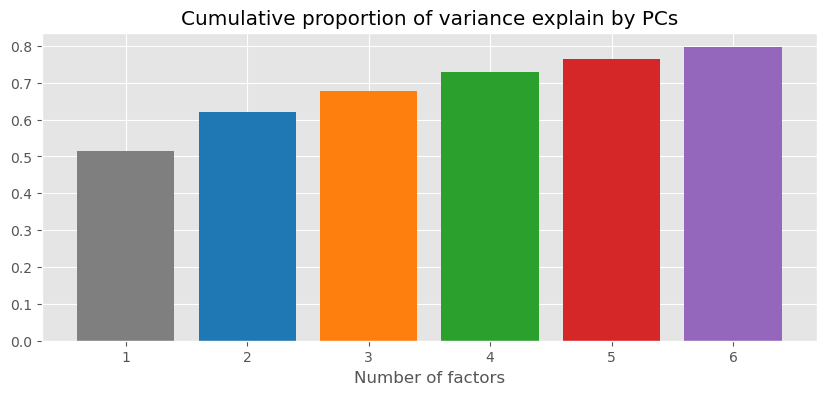

In [40]:
# plotting the coefficient score
fig, ax = plt.subplots(figsize=(10, 4))
color = [
    "tab:gray",
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
    "tab:orange",
    "tab:green",
    "tab:blue",
    "tab:olive",
]
ax.bar(list(range(1, 7)), np.cumsum(pca.explained_variance_ratio_), color=color)
plt.style.use("ggplot")
plt.title("Cumulative proportion of variance explain by PCs")
plt.xlabel("Number of factors")
plt.show()

## **3. BUILDING A LINEAR AUTOENCODER WITH TENSORFLOW**

Below we build a single-layer linear autoencoder with TensorFlow via [subclassing](https://www.tensorflow.org/guide/keras/custom_layers_and_models). The autoencoder has two Dense (fully connected) layers: an encoder, which compresses the data into a latent vector with a dimension set by "bottleneck_dim," and a decoder, which reconstructs the original input from the latent space.

In [41]:
import tensorflow as tf

In [42]:
class autoencoder(tf.keras.Model):
    def __init__(self, output_dim, bottleneck_dim=1):
        super(autoencoder, self).__init__()
        self.output_dim = output_dim
        self.bottleneck_dim = bottleneck_dim
        initializer = tf.keras.initializers.GlorotUniform()
        # Build the encoder layer
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    bottleneck_dim,
                    kernel_initializer=initializer,
                    bias_initializer=tf.keras.initializers.Zeros(),
                )
            ]
        )
        # Build the decoder layer
        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(
                    output_dim,
                    kernel_initializer=initializer,
                    bias_initializer=tf.keras.initializers.Zeros(),
                )
            ]
        )

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Below we compile and train the model using our training data. We choose a "bottleneck" with 3 latent factors. We train the model for at most 1,000 epochs, setting an early stopping criterion using a validation sample of 20% of all the training observations. The early stopping criterion may not bind, depending on the particular seed used in the training algorithm.

In [43]:
# Choose the number of latent factors
nlatent = 3
# Choose the proportion of training data used for validation
val_split = 0.2
# Determine early stopping criterion
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50)
# Choose optimizer
adam = tf.keras.optimizers.Adam(learning_rate=1e-4)
# Build and compile the model
model = autoencoder(Y_train.shape[1], nlatent)
model.compile(optimizer=adam, loss="mse")
# Train the model
model.fit(
    x=Y_train,
    y=Y_train,
    batch_size=32,
    epochs=10,
    validation_split=val_split,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


31/31 [==============================] - 1s 14ms/step - loss: 7.3798e-04 - val_loss: 5.3900e-04
Epoch 2/10
31/31 [==============================] - 0s 7ms/step - loss: 7.2096e-04 - val_loss: 5.3046e-04
Epoch 3/10
31/31 [==============================] - 0s 7ms/step - loss: 7.0539e-04 - val_loss: 5.2372e-04
Epoch 4/10
31/31 [==============================] - 0s 7ms/step - loss: 6.9160e-04 - val_loss: 5.1674e-04
Epoch 5/10
31/31 [==============================] - 0s 7ms/step - loss: 6.7838e-04 - val_loss: 5.1060e-04
Epoch 6/10
31/31 [==============================] - 0s 7ms/step - loss: 6.6611e-04 - val_loss: 5.0492e-04
Epoch 7/10
31/31 [==============================] - 0s 9ms/step - loss: 6.5513e-04 - val_loss: 4.9980e-04
Epoch 8/10
31/31 [==============================] - 0s 7ms/step - loss: 6.4492e-04 - val_loss: 4.9540e-04
Epoch 9/10
31/31 [==============================] - 0s 7ms/step - loss: 6.3529e-04 - val_loss: 4.9082e-04
Epoch 10/10
31/31 [==============================] - 0s 

We can analyze the performance of the linear autoencoder by extracting the reconstruction error of the model in the training and test samples. We compute, similar to computing $1{-}R^2$ in regression settings, the proportion of the variance of the inputs that is left unexplained by the model.

Remember that the lower bound on the in-sample reconstruction error, using a linear autoencoder and an MSE loss, is set by the sum of the principal eigenvalues $k+1, ..., n$. From above, we obtained that the first three principal components explain roughly 67% of the variation in the data. The trained autoencoder has a reconstruction error of 32%, meaning that the error is close to the minimum possible when using a three-dimensional encoding.

Importantly, notice that we are using a validation sample with an early stopping criterion to avoid overfitting. This means that training may stop before the lower bound is achieved, so we should not necessarily reach the PCA's minimum reconstruction error using the trained autoencoder.

Below, we report the reconstruction error of the model in the training set and validation set separately. The results depend on the random seed that initializes the training algorithm. However, after several runs, the model should display a relatively good out-of-sample performance in terms of reconstruction error.

In [44]:
Y_pred = model.predict(Y_train, verbose=0)
error = np.sum((Y_train - Y_pred) ** 2) / np.sum((Y_train - np.mean(Y_train)) ** 2)
print("Reconstruction error in training sample", error)
Y_pred = model.predict(Y_test, verbose=0)
error_oos = np.sum((Y_test - Y_pred) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
print("Reconstruction error in test sample", error_oos)

Reconstruction error in training sample 1.228147221191132
Reconstruction error in test sample 1.1467886350571475


We can recover the time series of each latent factor generated by the autoencoder. Notice that the latent factors recovered by the autoencoder are correlated, as opposed to the PCA factors. Besides, the autoencoder factors are not ordered in terms of total variation.

In [45]:
factors = model.encoder(Y_train).numpy()
factors_test = model.encoder(Y_test).numpy()
factors_cov = np.cov(factors, rowvar=False)
print(factors_cov)

[[ 9.43795758e-04  1.74823110e-04  1.41108319e-04]
 [ 1.74823110e-04  3.10100585e-04 -9.00619184e-05]
 [ 1.41108319e-04 -9.00619184e-05  5.98422955e-04]]


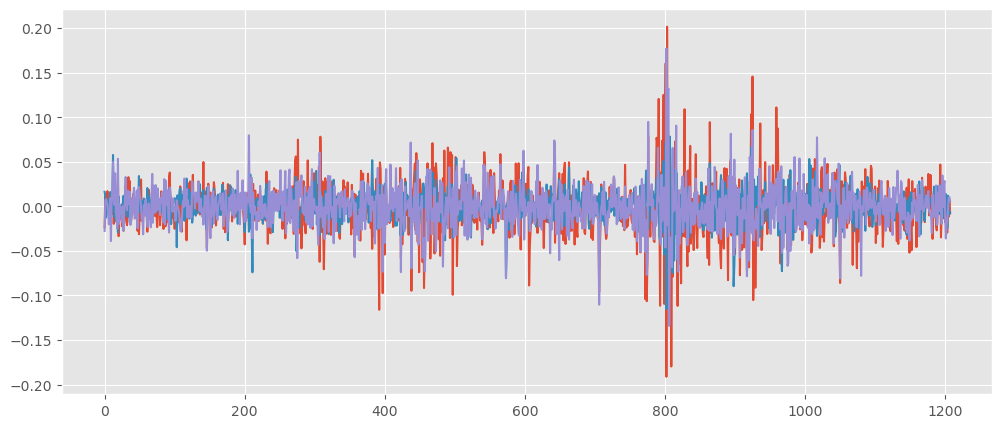

In [46]:
# Plot the evolution of latent factors in the training period
plt.figure(figsize=(12, 5))
plt.plot(factors)
plt.show()

Although the results may vary depending on the seed, the highest-variance latent factor recovered by the autoencoder tends to capture the average level of returns across the stocks considered. The second latent factor in terms of variance seems to capture variations in the cross-sectional standard deviation of returns. That is, when the second factor takes a high value it seems that returns across stocks are more disperse.

*Note: The red dashed line denotes the end of the training sample.*

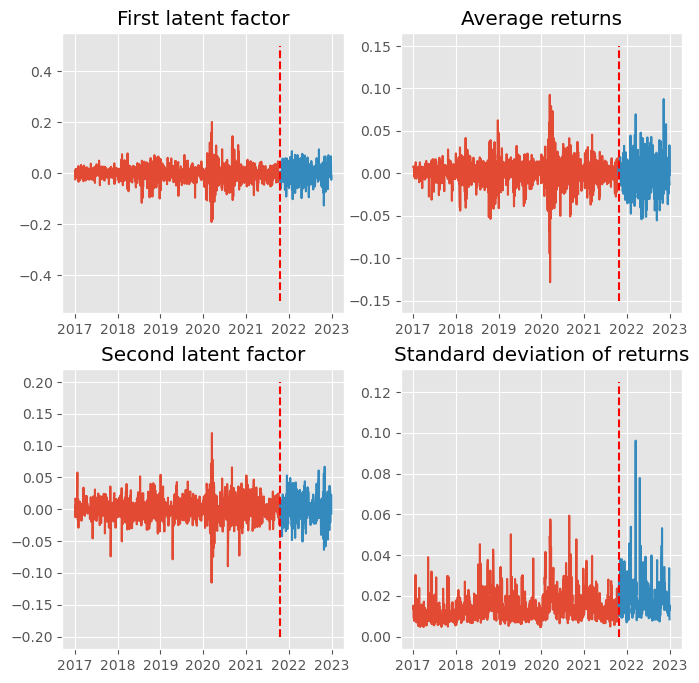

In [47]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# First factor
axs[0, 0].plot(df.index[: train_size + 1], factors[:, 0])
axs[0, 0].plot(df.index[train_size + 1 :], factors_test[:, 0])
axs[0, 0].plot([df.index[train_size + 1], df.index[train_size + 1]], [-0.5, 0.5], "r--")
axs[0, 0].title.set_text("First latent factor")
# Average of returns
axs[0, 1].plot(df.index[: train_size + 1], np.mean(Y_train, axis=1))
axs[0, 1].plot(df.index[train_size + 1 :], np.mean(Y_test, axis=1))
axs[0, 1].plot(
    [df.index[train_size + 1], df.index[train_size + 1]], [-0.15, 0.15], "r--"
)
axs[0, 1].title.set_text("Average returns")
# Second factor
axs[1, 0].plot(df.index[: train_size + 1], factors[:, 1])
axs[1, 0].plot(df.index[train_size + 1 :], factors_test[:, 1])
axs[1, 0].plot([df.index[train_size + 1], df.index[train_size + 1]], [-0.2, 0.2], "r--")
axs[1, 0].title.set_text("Second latent factor")
# Standard deviation of returns
axs[1, 1].plot(df.index[: train_size + 1], np.std(Y_train, axis=1))
axs[1, 1].plot(df.index[train_size + 1 :], np.std(Y_test, axis=1))
axs[1, 1].plot(
    [df.index[train_size + 1], df.index[train_size + 1]], [0.0, 0.125], "r--"
)
axs[1, 1].title.set_text("Standard deviation of returns")

How is each stock in our sample exposed to each of the latent factors extracted by the autoencoder? This exposure is measured by each stock's loadings (the trainable weights in the output layer). Below, we generate scatter plots that display the relationship between the loadings of each stock on each pair of factors.

Noticeably, Tesla represents a clear outlier, a results that tends to appear regardless of the random seed that is used in the training algorithm. This suggests that a large portion of the cross-sectional variation in stock returns is actually driven by the behavior of Tesla's stock price. In other words, Tesla's stock price displays a behavior of its own that is separate from other stocks.

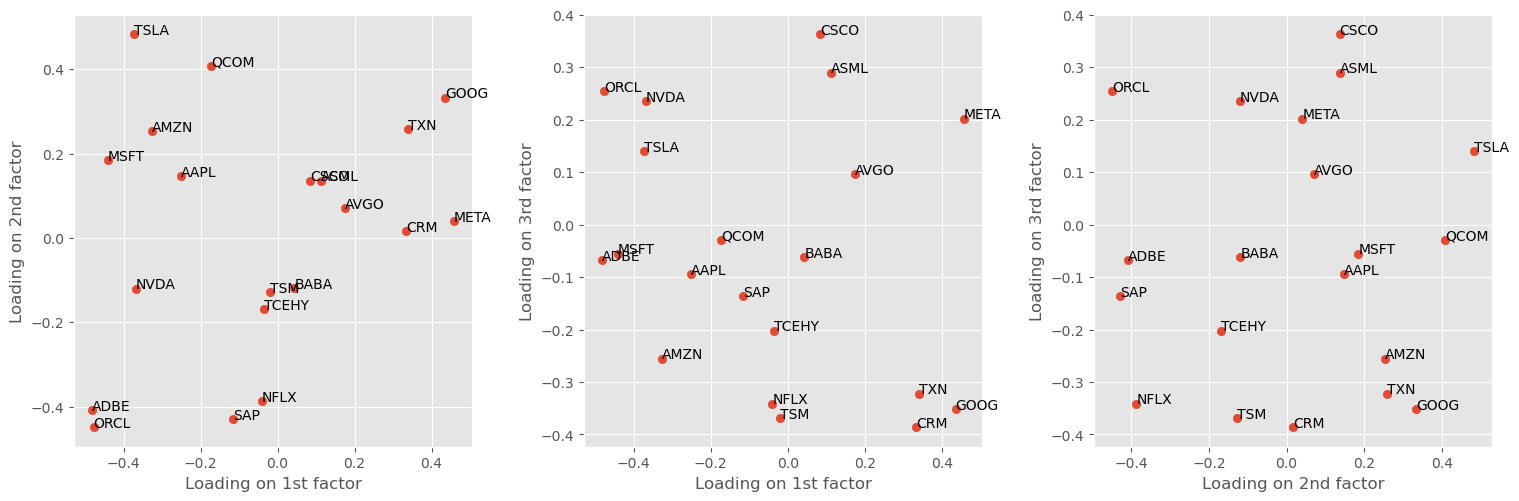

In [48]:
# Extract loadings generated by the autoencoder
w_decoder = model.decoder.layers[0].get_weights()[0]
fig, axs = plt.subplots(1, 3, figsize=(16, 6))
fig.tight_layout(pad=5.0)
axs[0].scatter(w_decoder[0], w_decoder[1])
axs[0].set_ylabel("Loading on 2nd factor")
axs[0].set_xlabel("Loading on 1st factor")
axs[1].scatter(w_decoder[0], w_decoder[2])
axs[1].set_ylabel("Loading on 3rd factor")
axs[1].set_xlabel("Loading on 1st factor")
axs[2].scatter(w_decoder[1], w_decoder[2])
axs[2].set_ylabel("Loading on 3rd factor")
axs[2].set_xlabel("Loading on 2nd factor")
for i, txt in enumerate(tickers):
    axs[0].annotate(txt, (w_decoder[0, i], w_decoder[1, i]))
    axs[1].annotate(txt, (w_decoder[0, i], w_decoder[2, i]))
    axs[2].annotate(txt, (w_decoder[1, i], w_decoder[2, i]))

## **4. AN AUTOENCODER WITH NON-LINEAR ACTIVATIONS**

In the blocks of code below we build and train an autoencoder that includes two additional hidden layers, one on each side of the bottleneck, with non-linear activations. The trained model displays slightly less reconstruction error than the linear benchmark in the training sample, although the error in the test sample is approximately the same.

The non-linear autoencoder may be able to capture richer features than the linear version. However, it becomes harder to grasp the type of variation that each latent factor is recovering from the data. As we show below in the figures, the factors are not so tightly related to average returns or dispersion, while the presence of an intermediate hidden layer makes it hard to grasp the exposure of each stock to the latent factors. Thus, adding non-linearities and hidden layers may enhance the explanatory ability of our models, but we likely lose a great deal of interpretability.

In [49]:
class autoencoder_nonlinear(tf.keras.Model):
    def __init__(self, output_dim, bottleneck_dim=1):
        super(autoencoder_nonlinear, self).__init__()
        self.output_dim = output_dim
        self.bottleneck_dim = bottleneck_dim
        act_fun = "relu"
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(12, activation=act_fun),
                tf.keras.layers.Dense(bottleneck_dim),
            ]
        )
        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(12, activation=act_fun),
                tf.keras.layers.Dense(output_dim),
            ]
        )

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [50]:
nlatent = 3
# to make this notebook's output stable
# np.random.seed(42)
# tf.random.set_seed(42)
val_split = 0.2
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50)
model_nonlinear = autoencoder_nonlinear(Y_train.shape[1], nlatent)
adam = tf.keras.optimizers.Adam(learning_rate=1e-4)
model_nonlinear.compile(optimizer=adam, loss="mse")
model_nonlinear.fit(
    x=Y_train,
    y=Y_train,
    batch_size=32,
    epochs=10,
    validation_split=val_split,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/10
31/31 [==============================] - 1s 17ms/step - loss: 4.9906e-04 - val_loss: 3.9402e-04
Epoch 2/10
31/31 [==============================] - 0s 10ms/step - loss: 4.8087e-04 - val_loss: 3.8603e-04
Epoch 3/10
31/31 [==============================] - 0s 10ms/step - loss: 4.7008e-04 - val_loss: 3.7978e-04
Epoch 4/10
31/31 [==============================] - 0s 10ms/step - loss: 4.6063e-04 - val_loss: 3.7439e-04
Epoch 5/10
31/31 [==============================] - 0s 7ms/step - loss: 4.5187e-04 - val_loss: 3.6942e-04
Epoch 6/10
31/31 [==============================] - 0s 9ms/step - loss: 4.4390e-04 - val_loss: 3.6435e-04
Epoch 7/10
31/31 [==============================] - 0s 7ms/step - loss: 4.3632e-04 - val_loss: 3.5982e-04
Epoch 8/10
31/31 [==============================] - 0s 7ms/step - loss: 4.2921e-04 - val_loss: 3.5579e-04
Epoch 9/10
31/31 [==============================] - 0s 7ms/step - loss: 4.2233e-04 - val_loss: 3.5137e-04
Epoch 10/10
31/31 [=======================

In [51]:
Y_pred = model_nonlinear.predict(Y_train, verbose=0)
error_non = np.sum((Y_train - Y_pred) ** 2) / np.sum((Y_train - np.mean(Y_train)) ** 2)
print("Reconstruction error in training sample", error_non)
Y_pred = model_nonlinear.predict(Y_test, verbose=0)
error_non_oos = np.sum((Y_test - Y_pred) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
print("Reconstruction error in test sample", error_non_oos)

Reconstruction error in training sample 0.8246888145828255
Reconstruction error in test sample 0.8109457037630315


In [52]:
factors = model_nonlinear.encoder(Y_train).numpy()
factors_test = model_nonlinear.encoder(Y_test).numpy()
print(np.cov(factors, rowvar=False))

[[ 0.00018274  0.00034631 -0.00011722]
 [ 0.00034631  0.00114262 -0.00047609]
 [-0.00011722 -0.00047609  0.00035747]]


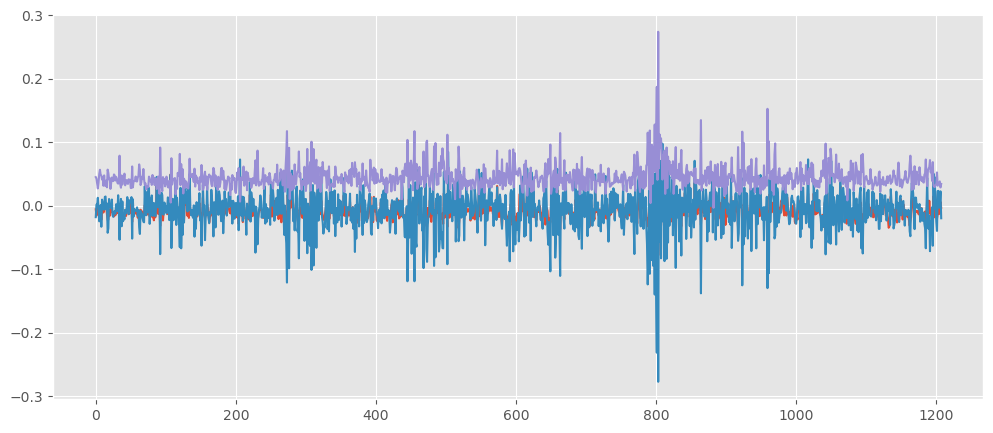

In [53]:
# Plot the evolution of latent factors in the training period
plt.figure(figsize=(12, 5))
plt.plot(factors)
plt.show()

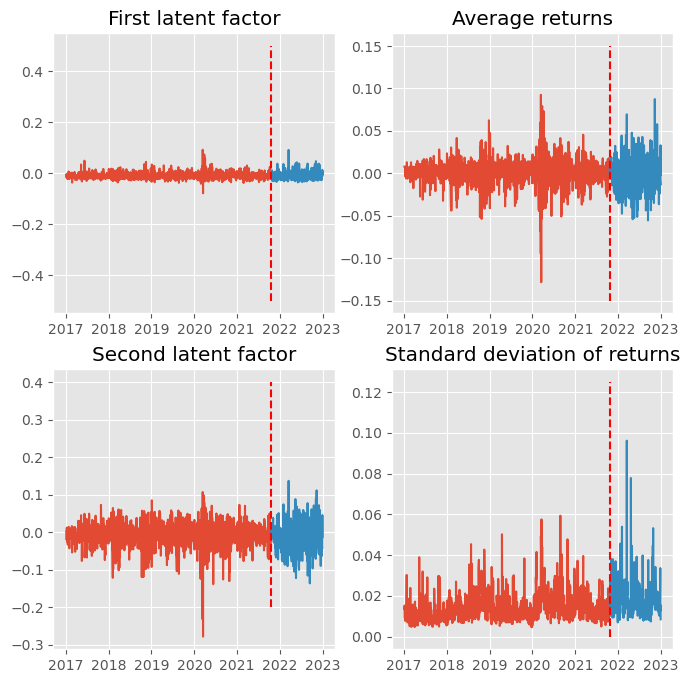

In [54]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# First factor
axs[0, 0].plot(df.index[: train_size + 1], factors[:, 0])
axs[0, 0].plot(df.index[train_size + 1 :], factors_test[:, 0])
axs[0, 0].plot([df.index[train_size + 1], df.index[train_size + 1]], [-0.5, 0.5], "r--")
axs[0, 0].title.set_text("First latent factor")
# Average of returns
axs[0, 1].plot(df.index[: train_size + 1], np.mean(Y_train, axis=1))
axs[0, 1].plot(df.index[train_size + 1 :], np.mean(Y_test, axis=1))
axs[0, 1].plot(
    [df.index[train_size + 1], df.index[train_size + 1]], [-0.15, 0.15], "r--"
)
axs[0, 1].title.set_text("Average returns")
# Second factor
axs[1, 0].plot(df.index[: train_size + 1], factors[:, 1])
axs[1, 0].plot(df.index[train_size + 1 :], factors_test[:, 1])
axs[1, 0].plot([df.index[train_size + 1], df.index[train_size + 1]], [-0.2, 0.4], "r--")
axs[1, 0].title.set_text("Second latent factor")
# Standard deviation of returns
axs[1, 1].plot(df.index[: train_size + 1], np.std(Y_train, axis=1))
axs[1, 1].plot(df.index[train_size + 1 :], np.std(Y_test, axis=1))
axs[1, 1].plot(
    [df.index[train_size + 1], df.index[train_size + 1]], [0.0, 0.125], "r--"
)
axs[1, 1].title.set_text("Standard deviation of returns")

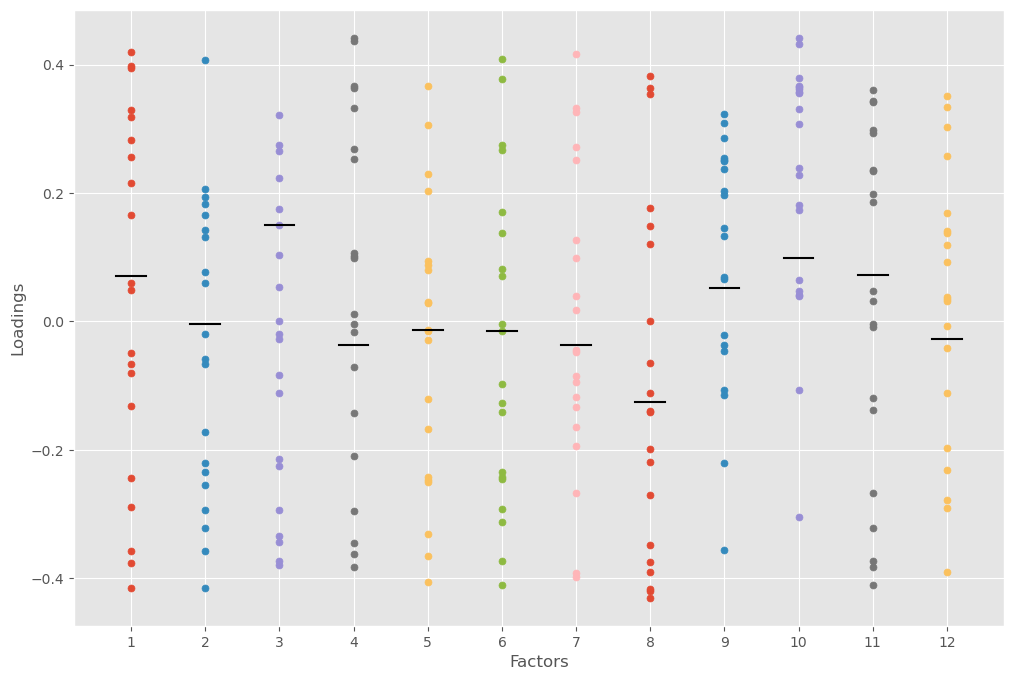

In [55]:
# Extract loadings generated by the autoencoder in the output layer
w_decoder = model_nonlinear.decoder.layers[1].get_weights()[0]
data = w_decoder
labels = list(range(1, 13))
width = 0.4
fig, ax = plt.subplots(figsize=(12, 8))
for i, l in enumerate(labels):
    x = np.ones(data.shape[1]) * i
    ax.scatter(x, data[i, :], s=25)
    mean = data[:, i].mean()
    ax.plot([i - width / 2.0, i + width / 2.0], [mean, mean], color="k")
    ax.set_xlabel("Factors")
    ax.set_ylabel("Loadings")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

plt.show()

## **5. CONCLUSION**

In this notebook, we have learned to design and train autoencoders with TensorFlow as a tool to extract the main latent factors that drive the variation of financial time series.

In the next lesson, we will explore tools to refine autoencoders and describe other types of architectures.

See you there!

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
